# Stellar Classification and Supervised Learning
This notebook demonstrates how to build, train, and evaluate multiple models (both traditional ML and PyTorch Neural Networks) using our custom `stellar_classification` package.

In [15]:
import sys, os, gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random


#sistemare il warning di LightGBM fa creare warning a tutti gli altri modelli addestrati senza
#feature name, quindi meglio ingorarli
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))
import stellar_classification as sc
from sklearn.metrics import accuracy_score
from stellar_classification.models.trees import SimpleRandomForest

#seed

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

# Enable garbage collection
gc.enable()
gc.collect()

2647

First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
 18  u_g          100000 non-

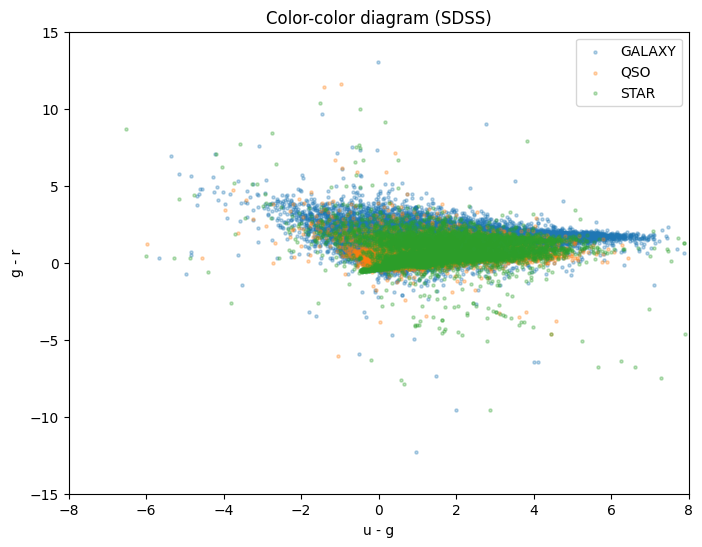

In [16]:
# Load dataset
data_path = '../stellar_classification/stellar_classification/data/star_classification.csv'
star = pd.read_csv(data_path)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]


print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

plt.figure(figsize=(8,6))

for c in star['class'].unique():
    subset = star[star['class'] == c]
    plt.scatter(subset['u_g'], subset['g_r'],
                label=c,
                s=5,
                alpha=0.3)
    plt.xlim(-8, 8)
    plt.ylim(-15, 15)

plt.xlabel('u - g')
plt.ylabel('g - r')
plt.legend()
plt.title('Color-color diagram (SDSS)')
plt.show()



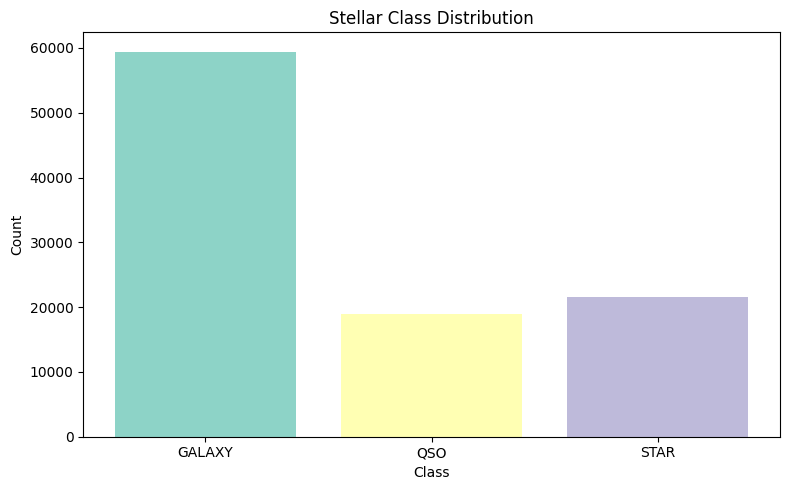

In [9]:
# Visualize Class Distribution
sc.plot_class_distribution(star['class'], title="Stellar Class Distribution")


In [17]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    label_encoder,
    scaler,
    feature_names,
    pca,
) = sc.prepare_splits(
    star,
    target_col='class',
    test_size=0.2,
    val_ratio=0.25,
    random_state=42,
    apply_outlier_removal=True
)

class_names = list(label_encoder.classes_)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

print(feature_names)

Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'plate', 'MJD', 'u_g', 'g_r', 'r_i', 'i_z']


## Random Forest and Extra Trees 

In [18]:
import importlib, sys
to_remove = [k for k in sys.modules if 'stellar_classification' in k]
for k in to_remove:
    del sys.modules[k]
import stellar_classification as sc

In [19]:
#train su random forest ed extra trees
models = sc.train_trees_with_tuning(X_train, y_train, X_val, y_val, n_iter=5, cv=3)
rf_model = models['Random Forest']
et_model = models['Extra Trees']

Random Forest best params: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': None, 'max_depth': None}
  [Train] Acc=98.01%  F1=0.9801
  [Val] Acc=90.01%  F1=0.8734
Extra Trees best params: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
  [Train] Acc=98.11%  F1=0.9811
  [Val] Acc=90.43%  F1=0.8774


In [ ]:
#evaluate test set
rf_metrics = sc.evaluate_test_set(y_test, rf_model.predict(X_test), 'Random Forest')
et_metrics = sc.evaluate_test_set(y_test, et_model.predict(X_test), 'Extra Trees')

sc.print_metrics(rf_metrics)
sc.print_metrics(et_metrics)

In [ ]:
from stellar_classification.models.trees import SimpleRandomForest, SimpleExtraTrees

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc.plot_learning_curve(
    SimpleRandomForest(**rf_model.get_params()),
    X_train, y_train,
    title='Learning Curve — Random Forest',
    ax=axes[0]
)

sc.plot_learning_curve(
    SimpleExtraTrees(**et_model.get_params()),
    X_train, y_train,
    title='Learning Curve — Extra Trees',
    ax=axes[1]
)

plt.tight_layout()
plt.show()


se le curve iniziano a convergere significa che ipoteticamente l'overfitting è dovuto ad una insufficienza di dati. Ed è il caso in cui ci troviamo. Se cosi non fosse invece, allora l'overfitting sarebbe causato da una complessità del modello, possiamo quindi concludere che l'overfitting non è puramente strutturale.

In [ ]:
#matrici di confusione per i due modelli 

sc.plot_confusion_matrix(rf_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Random Forest')
sc.plot_confusion_matrix(et_metrics['confusion_matrix'], class_names=class_names,
                         title='Confusion Matrix - Extra Trees')

In [ ]:
# Feature Ablation

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sc.plot_feature_ablation(rf_model, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — Random Forest',
                         ax=axes[0])

sc.plot_feature_ablation(et_model, X_train, X_test, y_train, y_test,
                         feature_names,
                         title='Feature Ablation — Extra Trees',
                         ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)

y_test_pred_rf = rf_model.predict(X_test)
y_test_pred_et = et_model.predict(X_test)

print("           RANDOM FOREST — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_rf,
    feature_x="g_r", feature_y="r_i",
    title_prefix="Random Forest"
)
print("           EXTRA TREES — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_et,
    feature_x="g_r", feature_y="r_i",
    title_prefix="Extra Trees"
)

In [ ]:
print("           RANDOM FOREST — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_rf,
    feature_x="u_g", feature_y="i_z",
    title_prefix="Random Forest"
)
print("           EXTRA TREES — Prediction & Error Map")
sc.plot_prediction_and_error_map(
    X_test_df, y_test, y_test_pred_et,
    feature_x="u_g", feature_y="i_z",
    title_prefix="Extra Trees"
)

In [ ]:
print("           RANDOM FOREST ")
sc.plot_misclassified_feature_distributions(
    X_test_df, y_test, y_test_pred_rf,
    features=["u_g", "g_r", "r_i", "i_z"],
    title_prefix="Random Forest"
)

print("           EXTRA TREES ")
sc.plot_misclassified_feature_distributions(
    X_test_df, y_test, y_test_pred_et,
    features=["u_g", "g_r", "r_i", "i_z"],
    title_prefix="Extra Trees"
)

In [ ]:
importance_functions= {
    "gini_importance": lambda m: m.feature_importances_
}



print("           RANDOM FOREST — Feature Importance")
df_imp_rf = sc.plot_feature_importance(
    rf_model,
    feature_names,
    importance_functions=importance_functions,
    
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    
    top_k=10,
    sort_by="permutation"
)



print("           EXTRA TREES — Feature Importance")
df_imp_et = sc.plot_feature_importance(
    et_model,
    feature_names,
    importance_functions=importance_functions,
    
    use_permutation=True,
    X_test=X_test,
    y_test=y_test,
    
    top_k=10,
    sort_by="permutation"
)

## XGBoost and LightGBM

In [20]:
#hyperparameter tuning xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_jobs=3)

params = {"n_estimators": [300,500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10],
}

best_model_xgb, best_params_xgb, best_score_xgb = sc.tune_model(
    xgb,
    params,
    X_train,
    y_train,
)

print("Best Hyperparameters:", best_params_xgb)

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [21]:
#xgboost training

best_params_xgb.pop("n_estimators", None)
best_params_xgb.pop("max_depth", None)

xgb_final = XGBClassifier(**best_params_xgb,n_estimators=1000,max_depth=3, objective="multi:softprob",
    eval_metric="mlogloss",
    early_stopping_rounds=50,
    tree_method="hist",
    random_state=42)
xgb_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],verbose=False)

train_metrics_xgb, val_metrics_xgb = sc.evaluate_single_model(
    xgb_final,
    X_train, y_train,
    X_val, y_val,
    model_name="XGBoost Tuned"
)

y_test_pred_xgb = xgb_final.predict(X_test)
xgb_metrics = sc.evaluate_test_set(y_test, y_test_pred_xgb, "XGBoost")
sc.print_metrics(xgb_metrics)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

[Training] Acc=91.3462% P=0.9136 R=0.9135 F1=0.9133
Confusion Matrix:
[[30560   929   855]
 [ 1602 29191  1551]
 [ 1268  2192 28884]]

[Validation] Acc=90.2120% P=0.8713 R=0.8797 F1=0.8749
Confusion Matrix:
[[10122   368   291]
 [  213  3088   247]
 [  268   400  3260]]


XGBoost:
  Accuracy  : 90.41%
  Precision: 0.8731
  Recall   : 0.8823
  F1       : 0.8773
  Confusion Matrix:
[[10129   366   286]
 [  219  3073   256]
 [  239   385  3304]]


In [22]:
#hyperparameter tuning lgbm

import os
os.environ["LIGHTGBM_VERBOSITY"] = "-1"
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_jobs=3,verbose=-1)
params = {"n_estimators": [300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "num_leaves": [15, 31], 
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 3, 10], 
  } 
   
best_model_lgbm, best_params_lgbm, best_score_lgbm = sc.tune_model(
    lgbm,
    params,
    X_train,
    y_train,verbose=False
)

print("Best Hyperparameters:", best_params_lgbm)
 

Best Hyperparameters: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [23]:
#lgbm training

best_params_lgbm.pop("n_estimators", None)
best_params_lgbm.pop("max_depth", None)
lgbm_final = LGBMClassifier(**best_params_lgbm,n_estimators=1000,max_depth=3,verbose=-1 )

import lightgbm as lgb
lgbm_final.fit(X_train, y_train,eval_set=[(X_val, y_val)],  eval_metric='multi_logloss',  callbacks=[lgb.early_stopping(50)])

train_metrics_lgbm, val_metrics_lgbm = sc.evaluate_single_model(
    lgbm_final,
    X_train, y_train,
    X_val, y_val,
    model_name="LightGBM Tuned"
)

y_test_pred_lgbm = lgbm_final.predict(X_test)
lgbm_metrics = sc.evaluate_test_set(y_test, y_test_pred_lgbm, "LightGBM")
sc.print_metrics(lgbm_metrics)

X_test_df = pd.DataFrame(X_test, columns=feature_names)



Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[990]	valid_0's multi_logloss: 0.290654
[Training] Acc=91.6759% P=0.9168 R=0.9168 F1=0.9167
Confusion Matrix:
[[30627   930   787]
 [ 1576 29264  1504]
 [ 1174  2106 29064]]

[Validation] Acc=90.3215% P=0.8728 R=0.8802 F1=0.8759
Confusion Matrix:
[[10144   356   281]
 [  219  3081   248]
 [  264   399  3265]]


LightGBM:
  Accuracy  : 90.34%
  Precision: 0.8727
  Recall   : 0.8816
  F1       : 0.8767
  Confusion Matrix:
[[10122   367   292]
 [  226  3067   255]
 [  244   379  3305]]


In [ ]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(xgb_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - XGBoost Tuned')

sc.plot_confusion_matrix(lgbm_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - LightGBM Tuned')

In [ ]:
#shap xgboost
shap_values_xgb = sc.shap_summary_tree_model(
    model=xgb_final,
    X=X_test,
    feature_names=feature_names,
    class_names=label_encoder.classes_
)


In [ ]:
#shap lightgbm
shap_values_lgbm = sc.shap_summary_tree_model(
    model=lgbm_final,
    X=X_test,
    feature_names=feature_names,
    class_names=label_encoder.classes_
)

In [ ]:
print("          XGBoost — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost"
)


print("            LightGBM — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="LightGBM"
)

In [ ]:
print("          XGBoost — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="XGBoost")


print("            LightGBM — Prediction & Error Map")

sc.plot_prediction_and_error_map(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    feature_x="u_g",
    feature_y="i_z",
    title_prefix="LightGBM")



In [ ]:
sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"]
)

sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    features=["u_g", "g_r", "r_i", "i_z"]
)

In [ ]:
sc.plot_misclassified_feature_distributions_separated(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"],
    prefix_name="XGBoost",

)


sc.plot_misclassified_feature_distributions_separated(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    features=["u_g", "g_r", "r_i", "i_z"],
    prefix_name="LightGBM"
)

In [ ]:
sc.plot_misclassified_stacked_hist(
    X_test_df,
    y_test,
    y_test_pred_xgb,
    features=["u_g", "g_r", "r_i", "i_z"],
    prefix_name="XGBoost"
)


sc.plot_misclassified_stacked_hist(
    X_test_df,
    y_test,
    y_test_pred_lgbm,
    features=["u_g", "g_r", "r_i", "i_z"],
    prefix_name="LightGBM"
)

In [ ]:
results_xgb = sc.predict_with_confidence(
    model=xgb_final,
    X_test=X_test,
    X_plot=X_test_df,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="XGBoost",
    threshold=0.9,
)

final_pred_xgb = results_xgb["final_predictions"]
confidence_xgb = results_xgb["confidence"]



results_lgbm = sc.predict_with_confidence(
    model=lgbm_final,
    X_test=X_test,
    X_plot=X_test_df,
    feature_x="g_r",
    feature_y="r_i",
    title_prefix="LightGBM",
    threshold=0.9,
)

final_pred_lgbm = results_lgbm["final_predictions"]
confidence_lgbm = results_lgbm["confidence"]



In [ ]:
importance_functions_xgb = {

    "model_importance":
        lambda m: m.feature_importances_,

    "gain":
        lambda m: np.array([
            m.get_booster().get_score(
                importance_type="gain"
            ).get(f"f{i}", 0)
            for i in range(len(feature_names))
        ]),

    "weight":
        lambda m: np.array([
            m.get_booster().get_score(
                importance_type="weight"
            ).get(f"f{i}", 0)
            for i in range(len(feature_names))
        ])
}

df_imp = sc.plot_feature_importance(
    xgb_final,
    feature_names,
    prefix_name="XGBoost",

    importance_functions=importance_functions_xgb,

    use_permutation=True,
    X_test=X_test,
    y_test=y_test,

    top_k=15,
    sort_by="permutation"
)


importance_functions_lgbm = {

    # sklearn-style importance
    "model_importance":
        lambda m: m.feature_importances_,

    # numero split
    "split":
        lambda m: m.booster_.feature_importance(
            importance_type="split"
        ),

    # gain totale
    "gain":
        lambda m: m.booster_.feature_importance(
            importance_type="gain"
        )
}

df_imp = sc.plot_feature_importance(
    lgbm_final,
    feature_names,
    prefix_name="LightGBM",

    importance_functions=importance_functions_lgbm,

    use_permutation=True,
    X_test=X_test,
    y_test=y_test,

    top_k=15,
    sort_by="permutation"
)

In [ ]:
xgb_lc = XGBClassifier(**xgb_final.get_params())

# removed early stopping
xgb_lc.set_params(early_stopping_rounds=None)

sc.plot_learning_curve(
    xgb_lc,
    X_train,
    y_train
)




lgbm_lc = LGBMClassifier(**lgbm_final.get_params())

# removed early stopping
lgbm_lc.set_params(early_stopping_rounds=None)

sc.plot_learning_curve(
    lgbm_lc,
    X_train,
    y_train
)




In [ ]:
#feature ablation
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

xgb_ablation = XGBClassifier(
    n_estimators=1000,   
    max_depth=xgb_final.max_depth,
    learning_rate=xgb_final.learning_rate,
    subsample=xgb_final.subsample,
    colsample_bytree=xgb_final.colsample_bytree,
    random_state=42
)
xgb_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(xgb_ablation, X_train, X_test, y_train, y_test,
                         feature_names, 
                         title='Feature Ablation — XGBoost',
                         ax=axes[0])


lgbm_ablation = LGBMClassifier(
    n_estimators=1000,
    max_depth=lgbm_final.max_depth,
    learning_rate=lgbm_final.learning_rate,
    subsample=lgbm_final.subsample,
    colsample_bytree=lgbm_final.colsample_bytree,
    reg_alpha=lgbm_final.reg_alpha,
    reg_lambda=lgbm_final.reg_lambda,
)
lgbm_ablation.fit(X_train, y_train)
sc.plot_feature_ablation(lgbm_ablation, X_train, X_test, y_train, y_test,
                         feature_names,
                         title='Feature Ablation — LightGBM',
                         ax=axes[1])

axes[0].set_ylim(50, 100)
axes[1].set_ylim(50, 100)
plt.tight_layout()
plt.show()

# Neural Networks


In [ ]:
# Convert numpy arrays to PyTorch DataLoaders
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    batch_size=64
)


print("DataLoaders created.")


In [ ]:
# ============================================================
# Neural Network setup
# ============================================================

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Input size:", input_size)
print("Number of classes:", num_classes)

In [ ]:
# ============================================================
# Import experiment runner
# ============================================================

from stellar_classification.experiments.nn_runner import run_experiments

In [ ]:
# ============================================================
# Run Neural Network Experiments
# ============================================================

results_df = run_experiments(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,

    input_size=input_size,
    num_classes=num_classes,

    model_types=[
        "SimpleNN",
        "MediumNN",
        "ComplexNN",
    ],

    learning_rates=[
        0.01,
        0.001,
        0.0001,
    ],

    epochs=15,
)

In [ ]:
# ============================================================
# Results
# ============================================================

display(results_df)


In [ ]:
from stellar_classification.visualization.nn_plots import plot_training_history

In [ ]:
best_simple = results_df[results_df["model"] == "SimpleNN"].iloc[0]
best_medium = results_df[results_df["model"] == "MediumNN"].iloc[0]
best_complex = results_df[results_df["model"] == "ComplexNN"].iloc[0]


In [ ]:
plot_training_history(best_simple["history"], title="SimpleNN - Best Model")

In [ ]:
plot_training_history(best_medium["history"], title="MediumNN - Best Model")

In [ ]:
plot_training_history(best_complex["history"], title="ComplexNN - Best Model")

In [ ]:
dropout_results = sc.experiments.nn_runner.run_dropout_ablation(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    input_size=input_size,
    num_classes=num_classes,
    results_df=results_df,
    dropout_values=(0.2, 0.3, 0.5),
    epochs=15,
)


In [ ]:
dropout_results.sort_values(by="val_f1", ascending=False).head(10)

In [ ]:
best_medium_dropout = dropout_results[dropout_results["model"] == "MediumNN"].iloc[0]
best_complex_dropout = dropout_results[dropout_results["model"] == "ComplexNN"].iloc[0]

In [ ]:
from stellar_classification.visualization.nn_plots import plot_dropout_comparison

plot_dropout_comparison(
    best_medium["history"],
    best_medium_dropout["history"],
    title="MediumNN Comparison"
)

plot_dropout_comparison(
    best_complex["history"],
    best_complex_dropout["history"],
    title="ComplexNN Comparison"
)

In [ ]:
from stellar_classification.visualization.model_selection import get_final_candidates

final_sorted = get_final_candidates(
    results_df=results_df,
    dropout_results=dropout_results,
    top_k=3
)

display(final_sorted)

In [ ]:
from stellar_classification.experiments.nn_runner import device
from stellar_classification.inference.predictor import evaluate_neural

# Miglior modello assoluto
best_model_row = final_sorted.iloc[0]

best_metrics = evaluate_neural(
    test_loader=test_loader,
    model=best_model_row["trained_model"],
    device=device,
    model_name=f"{best_model_row['model']}"
)

# Stampa metriche
sc.print_metrics(best_metrics)

# Confusion matrix

class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(
    best_metrics["confusion_matrix"],
    class_names=class_names,
    title=f"Confusion Matrix - {best_model_row['model']}"
)


In [ ]:
plot_training_history(best_model_row["history"], title="Best Model")

In [ ]:
from stellar_classification.utils.wrapper import TorchModelWrapper

from stellar_classification.inference.predictor import compute_permutation_importance


wrapped_model = TorchModelWrapper(best_model_row["trained_model"], device)

imp = compute_permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    feature_names=feature_names,
    n_jobs=1
)

sc.plot_permutation_importance(imp, top_n=10)


In [ ]:
from stellar_classification.experiments.feature_ablation import run_feature_ablation

best_model_row = final_sorted.iloc[0]

importance_scores = imp

ablation_results = run_feature_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    feature_names=feature_names,
    best_model_row=best_model_row,
    input_size=X_train.shape[1],
    num_classes=num_classes,
    device=device,
    importance_scores=importance_scores,
    epochs=15
)

ablation_results

In [ ]:
from stellar_classification.visualization.model_selection import plot_feature_ablation_nn

best_val_f1 = final_sorted.iloc[0]["val_f1"]

plot_feature_ablation_nn(
    ablation_results,
    best_val_f1=best_val_f1
)

In [ ]:
from stellar_classification.experiments.feature_ablation import (
    get_feature_subset_threshold
)

best_subset = get_feature_subset_threshold(
    ablation_results,
    best_val_f1=best_model_row["val_f1"],
    threshold=0.95,
)

if best_subset is not None:
    print("\n===== 95% FEATURE SUBSET =====")
    print(f"Target F1       : {0.95 * best_model_row['val_f1']:.4f}")
    print(f"Reached F1      : {best_subset['val_f1']:.4f}")
    print(f"N. features     : {best_subset['n_features']}")
    print("\nSelected features:")
    for f in best_subset["features"]:
        print(f" - {f}")
else:
    print("No subset reached the required threshold.")

In [ ]:
print(
    f"Relative performance: "
    f"{100 * best_subset['val_f1'] / best_model_row['val_f1']:.2f}%"
)


## NN PCA

In [ ]:
from stellar_classification.data.preprocessing import prepare_splits
from stellar_classification.experiments.pca_ablation import (
    plot_explained_variance
)

# ============================================================
# PCA preprocessing
# ============================================================

(
    X_train_pca,
    X_val_pca,
    X_test_pca,
    y_train_pca,
    y_val_pca,
    y_test_pca,
    label_encoder_pca,
    scaler_pca,
    feature_names_pca,
    pca,
) = prepare_splits(
    star,
    target_col='class',
    test_size=0.2,
    val_ratio=0.25,
    random_state=42,
    apply_outlier_removal=True,

    # PCA
    apply_pca=True,
    n_components=None,
)

# Plot explained variance
plot_explained_variance(pca)

In [ ]:
from stellar_classification.experiments.pca_ablation import (
    run_pca_ablation
)

# ============================================================
# Best model
# ============================================================

best_model_row = final_sorted.iloc[0]

# ============================================================
# PCA ablation
# ============================================================

pca_results = run_pca_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,

    y_train=y_train,
    y_val=y_val,
    y_test=y_test,

    best_model_row=best_model_row,

    num_classes=num_classes,
    device=device,

    component_list=list(range(1, X_train.shape[1] + 1)),

    epochs=15,
)

display(pca_results)

In [ ]:
from stellar_classification.visualization.model_selection import (
    plot_pca_ablation
)

plot_pca_ablation(
    pca_results,
    best_val_f1=best_model_row["val_f1"],
)

# Voting and Stacking

In [24]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

SEED = 42

svc_model = LinearSVC(random_state=SEED)
svc_model.fit(X_train, y_train)
calibrated_svc = CalibratedClassifierCV(svc_model, cv=5)
calibrated_svc.fit(X_train, y_train)
xgb_params = xgb_final.get_params()
xgb_params.pop('early_stopping_rounds', None)  # rimuovi l'early stopping

xgb_for_ensemble = XGBClassifier(**xgb_params)


models = {
    'Linear SVC':    calibrated_svc,
    'Random Forest': rf_model,
    'Extra Trees':   et_model,
    'XGBoost':       xgb_for_ensemble,
    'LightGBM':      lgbm_final,
}

In [25]:
voting_clf = sc.train_voting(X_train, y_train, X_val, y_val, models=models, voting='hard')

Voting Classifier trained.
  [Training] Acc=93.99%  P=0.94  R=0.94  F1=0.94
  [Validation] Acc=90.50%  P=0.88  R=0.88  F1=0.88


# usare virtual machine 
(eliminare questo commento)

In [ ]:
from sklearn.model_selection import GridSearchCV

stacking_clf_base = sc.make_stacking_classifier(models=models, n_jobs=1)
param_grid = {
    'final_estimator__C': [0.1, 1, 10],
    'cv': [3, 5, 10],
}
grid = GridSearchCV(
    estimator=stacking_clf_base, param_grid=param_grid,
    scoring='f1_weighted', cv=3, verbose=2, n_jobs=1, return_train_score=True
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)

# === Stacking Classifier finale con parametri ottimali ===
stacking_clf = sc.train_stacking(
    X_train, y_train, X_val, y_val,
    models=models,
    cv=grid.best_params_['cv'],
    final_estimator=LogisticRegression(C=grid.best_params_['final_estimator__C'], max_iter=1000, random_state=SEED)
)

In [27]:
from sklearn.model_selection import cross_validate 
import warnings
warnings.filterwarnings('ignore')


X_search = np.concatenate([X_train, X_val], axis=0)
y_search = np.concatenate([y_train, y_val], axis=0)
print(f"X_search shape is: {X_search.shape} \ny_search shape is: {y_search.shape}")

cv_results = cross_validate(
    voting_clf,
    X_search, 
    y_search,
    cv=3,
    scoring='f1_weighted',
    n_jobs=1,
    return_train_score=True
)

print("Hard Voting - 3-fold Cross Validation:")
print(f"  Train F1: {cv_results['train_score'].mean():.4f} ± {cv_results['train_score'].std():.4f}")
print(f"  Val F1:   {cv_results['test_score'].mean():.4f} ± {cv_results['test_score'].std():.4f}")
print(f"  Gap:      {abs(cv_results['train_score'].mean() - cv_results['test_score'].mean()):.4f}")


X_search shape is: (115289, 13) 
y_search shape is: (115289,)
Hard Voting - 3-fold Cross Validation:
  Train F1: 0.9378 ± 0.0026
  Val F1:   0.9111 ± 0.0036
  Gap:      0.0267


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

y_test_pred_voting = voting_clf.predict(X_test)
voting_metrics = sc.evaluate_test_set(y_test, y_test_pred_voting, "Voting Classifier")
sc.print_metrics(voting_metrics)

y_test_pred_stacking = stacking_clf.predict(X_test)
stacking_metrics = sc.evaluate_test_set(y_test, y_test_pred_stacking, "Stacking Classifier")
sc.print_metrics(stacking_metrics)

# Soft voting comparison

Soft voting weight combination search

In [ ]:
# from sklearn.model_selection import cross_validate
# from sklearn.ensemble import VotingClassifier
# import numpy as np

# X_search = np.concatenate([X_train, X_val], axis=0)
# y_search = np.concatenate([y_train, y_val], axis=0)
# print(f"X_search shape is: {X_search.shape} \ny_search shape is: {y_search.shape}")

# weight_combinations = [
#     [1, 1, 1, 1],
#     [1, 2, 2, 2],
#     [1, 1, 2, 2],
#     [1, 2, 3, 3],
#     [1, 1, 3, 3],
#     [2, 3, 3, 3],
# ]

# results = []

# estimators = [
#     ('dt',   models['Decision Tree']),
#     ('rf',   models['Random Forest']),
#     ('lgbm', models['LightGBM']),
#     ('xgb',  models['XGBoost']),
# ]

# for weights in weight_combinations:
#     clf = VotingClassifier(estimators=estimators, voting='soft', weights=weights)
    
#     cv_results = cross_validate(
#         clf, X_search, y_search,
#         cv=3,
#         scoring='f1_weighted',
#         n_jobs=1,
#         return_train_score=True
#     )
    
#     train_f1 = cv_results['train_score'].mean()
#     val_f1 = cv_results['test_score'].mean()
#     gap = abs(train_f1 - val_f1)
    
#     results.append({
#         'weights': weights,
#         'train_f1': train_f1,
#         'val_f1': val_f1,
#         'gap': gap
#     })
#     print(f"weights={weights} -> train_f1={train_f1:.4f} val_f1={val_f1:.4f} gap={gap:.4f}")

# results_df = pd.DataFrame(results).sort_values('gap')
# display(results_df)


In [ ]:


best_weights = results_df.iloc[0]['weights']
print("Best weights:", best_weights)

soft_voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=best_weights
)
soft_voting_clf.fit(X_train, y_train)



# grafici

In [ ]:
class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(voting_metrics['confusion_matrix'], class_names=class_names, title='Confusion Matrix - Voting Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/voting_matrix_cv')
sc.plot_confusion_matrix(stacking_metrics['confusion_matrix'], class_names=class_names, title='Confusion matrix - Stacking Classifier', save_path='/home/nikko/Immagini/res/conf_matrix/staking_matrix_index_NOz')


In [ ]:
imp = sc.compute_permutation_importance(voting_clf, X_test, y_test, feature_names=feature_names, n_jobs=4)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/voting_cv.png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}")

imp = sc.compute_permutation_importance(stacking_clf, X_test, y_test, feature_names=feature_names, n_jobs=4)
sc.plot_permutation_importance(imp, top_n=10, save_path='/home/nikko/Immagini/res/permutation_importances/stacking_perm_index_NOz.png')

print("Feature Importance Scores:")
for feat, val in imp.items():
    print(f"{feat}: {val:.4f}") 

In [ ]:


sc.plot_feature_ablation(
    voting_clf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    feature_names=feature_names,
    title='Feature Ablation - Voting Classifier',
    save_path='/home/nikko/Immagini/res/ablation/Voting_ablation(cv).png'
)

sc.plot_feature_ablation(
    stacking_clf,
    X_train,
    X_test,
    y_train,
    y_test,
    feature_names,
    title='Feature Ablation - Stacking model',
    save_path='/home/nikko/Immagini/res/ablation/Stacking_ablation.png'
)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

meta = stacking_clf.final_estimator_

col_names = [
    f"{name}_{cls}" 
    for name, _ in stacking_clf.estimators
    for cls in label_encoder.classes_
]

coef_df = pd.DataFrame(
    meta.coef_,
    columns=col_names,
    index=label_encoder.classes_
)

print("Meta-learner coefficients: weight of the vote")
display(coef_df)



fig, ax = plt.subplots(figsize=(14, 4))

sns.heatmap(
    coef_df,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    linewidths=0.5
)

ax.set_title('Meta-learner Coefficient Analysis')
ax.set_xlabel('Base Learner Predictions')
ax.set_ylabel('Class')

plt.tight_layout()
plt.show()


In [ ]:
X_test_df = pd.DataFrame(X_test, columns=feature_names)
y_pred_voting = voting_clf.predict(X_test)
y_pred_stacking = stacking_clf.predict(X_test)

# g-r vs r-i
sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_voting,
    feature_x='g_r',
    feature_y='r_i',
    title_prefix='Voting Classifier',
    save_path='/home/nikko/Immagini/res/ablation/Voting_errors(1).png'
)

sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_stacking,
    feature_x='g_r',
    feature_y='r_i',
    title_prefix='Stacking Classifier',
    save_path='/home/nikko/Immagini/res/ablation/Stacking_errors(1).png'
)

# u-g vs i-z
sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_voting,
    feature_x='u_g',
    feature_y='i_z',
    title_prefix='Voting Classifier',
    save_path='/home/nikko/Immagini/res/ablation/Voting_errors(2).png'
)

sc.plot_prediction_and_error_map(
    X=X_test_df,
    y_true=y_test,
    y_pred=y_pred_stacking,
    feature_x='u_g',
    feature_y='i_z',
    title_prefix='Stacking Classifier',
    save_path='/home/nikko/Immagini/res/ablation/Stacking_errors(2).png'
)


In [ ]:


sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_pred_stacking,
    features=["u_g", "g_r", "r_i", "i_z"],
    save_patch='/home/nikko/Immagini/res/errors/stacking_mis(1).png'
)

sc.plot_misclassified_feature_distributions(
    X_test_df,
    y_test,
    y_pred_voting,
    features=["u_g", "g_r", "r_i", "i_z"],
    save_patch='/home/nikko/Immagini/res/errors/voting_mis(1).png'
)

